# 🧪 Project Final Report

This is the final project report for CS6101. It is started as a copy of the `Project_Proposal.ipynb` template for consistency.


# Problem Statement
I am trying to predict the ReactivePower of a wind turbine farm as a function of the other features in the dataset. Some features are definitely also derivative features of the environment conditions, such as the aforementioned component temperatures. At a minimum, I want to utilize:
1. `WindSpeed` (Obviously, this is a wind turbine!)
2. `WindDirection` (Obviously, this is a wind turbine!) - This is probably more related to weather conditions, so if I include the time-of-day or day-of-year, I may see some other correlations
3. `AmbientTemperature` (I don't think this should be a physical relationship, but I wonder if based upon the location of the wind farm, warmer days are more windy?)
4. `BladePitchAngle` (this will be more important when the power output is 0)
5. ~`TurbineStatus`~ - This input has been excluded since it has such a wildly variable set of values.
6. The other variables are listed above, since the cutoff threshold was 0.85 correlation coefficient. Most of them, I think, are too closely related as internal derived parameters, so should be excluded.

**Label Columns:** `WTG`: This is the unique identifier for the wind turbine in the farm. Since there is only one turbine monitored, it has one value, and is therefore not a useful feature. It's not even really a label.

Here is the link to the [Kaggle Dataset](https://www.kaggle.com/datasets/theforcecoder/wind-power-forecasting).


## Environment Setup

In [1]:
# You are not allowed to import any modules other than the ones already included in this notebook.
import os
import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Data Preprocessing - This comes from the proposal work
Because the proposal work already did most of the requirements, I am just copying it here, but reducing the number of cells for clarity. Here are the requirements which preprocessing must meet:
1. Load dataset using `gdown`
2. Remove missing values and extreme outliers
3. Clean and analyze regression label
4. Bin the label for classification - utilized `pdquant` to guarantee perfect bin level-cuts.
5. Encode categorical features - N/A in this dataset
6. Normalize numerical columns - additional work, separate cell at the bottom.

## Load the Data

> NOTE: This is taken directly from the Proposal notebook, but flattened into fewer cells with the instructions removed for clarity.

It also caches the .csv download for convenience, so the notebook can be rerun.

In [2]:
# Download the CSV file if it does not yet exist - caches between runs.
if 'turbine-data.csv' not in os.listdir():
    URL = "https://drive.google.com/file/d/1EA5TGwyZ4QYBocB4Q5s8rBNTdj2vkay8/view?usp=drive_link"
    gdown.download(id="1EA5TGwyZ4QYBocB4Q5s8rBNTdj2vkay8")
else:
    print("Data already cached, skipping download.")

raw_data = pd.read_csv('turbine-data.csv', index_col=0)
raw_data = raw_data.reset_index().rename(columns={'index': 'TimeStamp'})
# Remove columns that aren't relevant (eg metadata)
# ControlBoxTemperature has 2 values, WTG has 1.
# TurbineStatus has enormous range: [0, 65,746,528] <- excluding this since it dominates all other inputs.

# Print a table of each input variable (unscaled) as a sanity check against spurious input data.
print(raw_data.agg(['min', 'max']))

raw_data = raw_data.drop(columns=['ControlBoxTemperature', 'WTG', 'TurbineStatus'])

# Convert timestamp to fractional hours of the day.
raw_data['TimeOfDay'] = pd.to_datetime(raw_data['TimeStamp']).dt.hour + pd.to_datetime(
    raw_data['TimeStamp']).dt.minute / 60
raw_data['DayOfYear'] = pd.to_datetime(raw_data['TimeStamp']).dt.dayofyear

# Drop all non-numeric columns
raw_data = raw_data.select_dtypes(include=[np.number]).copy()
# Dropping NA here to ensure enough rows.
raw_data = raw_data.dropna().copy()

### END SOLUTION
print("Number of rows:", raw_data.shape[0])
print("Number of columns:", raw_data.shape[1])


Data already cached, skipping download.
                     TimeStamp  ActivePower  AmbientTemperatue  \
min  2017-12-31 00:00:00+00:00   -38.524659           0.000000   
max  2020-03-30 23:50:00+00:00  1779.032433          42.405597   

     BearingShaftTemperature  Blade1PitchAngle  Blade2PitchAngle  \
min                 0.000000        -43.156734        -26.443415   
max                55.088655         90.143610         90.017830   

     Blade3PitchAngle  ControlBoxTemperature  GearboxBearingTemperature  \
min        -26.443415                    0.0                   0.000000   
max         90.017830                    0.0                  82.237932   

     GearboxOilTemperature  ...  GeneratorWinding2Temperature  HubTemperature  \
min               0.000000  ...                      0.000000        0.000000   
max              70.764581  ...                    126.043018       47.996185   

     MainBoxTemperature  NacellePosition  ReactivePower   RotorRPM  \
min             

## Label Cleanup
Since the invalid data was already removed: NaN, text fields, etc, the goal here is to show the valid raw data _before_ and _after_ extrema cleanup and balancing. For clarity, both will show a regular histogram, then the quantile level-cuts which will ensure class labels _are balanced by construction_.

Update Notes: If we exclude limits as proposed `[100,1600]`, then the `RandomForest` regression operation is completely dominated by `GeneratorRPM`. By including the endpoints, we obtain a more balanced contribution of multiple variables.

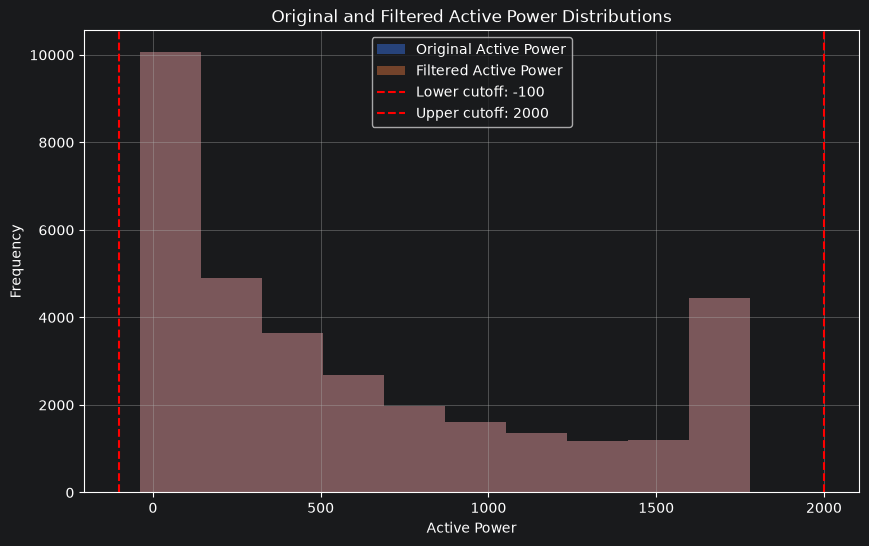

In [3]:
from sklearn.preprocessing import StandardScaler

label_name = 'ActivePower'
raw_data['Regression_Label'] = raw_data[label_name]

# Because `GeneratorRPM` correlates so strongly with `ActivePower`, remove that feature.
raw_data = raw_data.drop(columns='GeneratorRPM')

# Original: Because the histogram is imbalanced with 0s, remove those
# UPDATE: If we exclude the endpoints, then the regression model deteriorates to just `GeneratorRPM`.
lower_limit = -100  # 100
upper_limit = 2000 # 1600  # There's a lot at ~1750

plt.figure(figsize=(10, 6))
raw_data['Regression_Label'].hist(alpha=0.5, label='Original Active Power')
filtered_data = raw_data[(raw_data['Regression_Label'] > lower_limit) & (raw_data['Regression_Label'] < upper_limit)].copy()
filtered_data['Regression_Label'].hist(alpha=0.5, label='Filtered Active Power')
plt.axvline(lower_limit, color='red', linestyle='--', label=f'Lower cutoff: {lower_limit}')
plt.axvline(upper_limit, color='red', linestyle='--', label=f'Upper cutoff: {upper_limit}')
plt.xlabel('Active Power')
plt.ylabel('Frequency')
plt.title('Original and Filtered Active Power Distributions')
plt.legend()
plt.show()

data = filtered_data

# This bonus column is used for regression fitting convenience - it will be `StandardScalar`ed
data['SS_Regression'] = data['Regression_Label']
numeric_cols = raw_data.select_dtypes(include=[np.number]).columns
feature_numeric_cols = [col for col in numeric_cols if
                        col not in [label_name, 'Regression_Label', 'Classification_Label']]

## Feature Selection and Extraction
This is here to remove correlated features, such as BladePitchAngle, which will be monitored on all 3 blades, but for physics reasons must be essentially the same. As the Correlation Matrix below shows, those features at correlated at unity.
Additional correlation findings which are understandable:
1. `NacellePosition` vs `WindDirection`: This also makes sense, since the most efficient orientation is facing into the wind.
2. `GeneratorRPM` vs `MotorRPM`: This is expected, since the generator and motor are directly connected.
3. `AmbientTemperature` vs `MainBoxTemperature`: This is expected, since the hub/nacelle temperature is closely related to the ambient temperature, as well as the other system component temperatures.
   - You can see this with the cluster of `GearboxBearingTemperature`, `GearboxOilTemperature`, `GeneratorWinding1Temperature`, `GeneratorWinding2Temperature`: These are all related components, and because of the metal and oil they will have very similar temperatures.

## Input Variable Sanity Checking
Sometimes, the input variable can have many orders of magnitude of information, this is a set of histogram plots of the input space to ensure that the input variable ranges are sane.

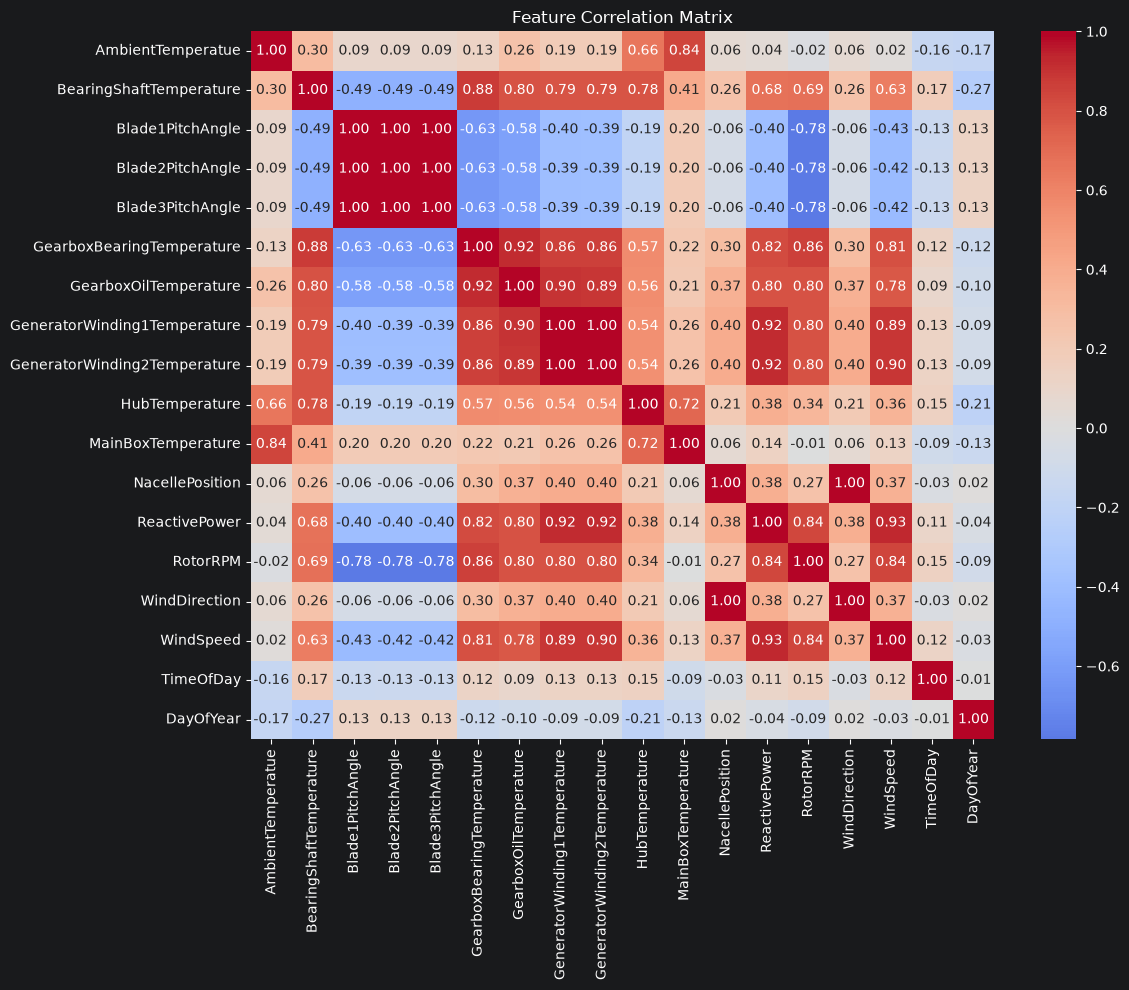

Removed features due to high correlation: ['GearboxBearingTemperature', 'Blade2PitchAngle', 'Blade3PitchAngle', 'GearboxOilTemperature', 'GeneratorWinding1Temperature', 'GeneratorWinding2Temperature', 'RotorRPM', 'ReactivePower', 'WindSpeed', 'WindDirection']
Number of Features selected:  8 ['AmbientTemperatue', 'BearingShaftTemperature', 'Blade1PitchAngle', 'HubTemperature', 'MainBoxTemperature', 'NacellePosition', 'TimeOfDay', 'DayOfYear']


In [4]:
# Get all numeric features except the labels
feature_cols = [col for col in data.columns if col not in ['Regression_Label', 'Classification_Label', 'SS_Regression', label_name]]
features_df = data[feature_cols].copy()

# Calculate correlation matrix
corr_matrix = features_df.corr()

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Identify highly correlated features (threshold of 0.85)
removed_features = []
correlation_threshold = 0.85 # NOTE - this is because there is cluster right around 0.85 for the GeneratorRPM and the gearbox temperatures. I want to include GeneratorRPM AND a temperature setting

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > correlation_threshold:
            colname = corr_matrix.columns[j]
            if colname not in removed_features:
                removed_features.append(colname)

print(f"Removed features due to high correlation: {removed_features}")

# Create final feature set
final_features = [col for col in feature_cols if col not in removed_features]
X = data[final_features]
print("Number of Features selected: ", X.shape[1], final_features)


## Bin Classification Labels
Because classification is easier with balanced classes, and this dataset has a continuous range, I am using `pd.qcut()` to bin the continuous label into 5 equal-sized bins. This guarantees balanced classes by construction, at the cost of interpretable labels if the the dataset were not continuous (eg holes in the histogram above).

Bin boundaries for each label:
Label 0: [-39, 24)
Label 1: [24, 257)
Label 2: [257, 586)
Label 3: [586, 1263)
Label 4: [1263, 1779)


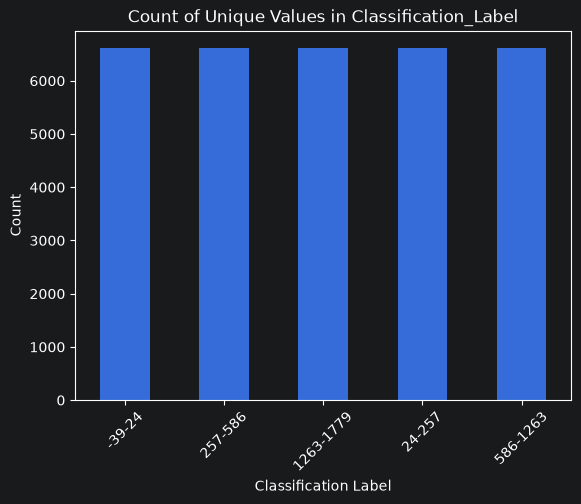

In [5]:
bins, labels = pd.qcut(data['Regression_Label'], q=5, retbins=True)
rounded_labels = np.rint(labels).astype(int)
bin_labels = [f"{rounded_labels[i]}-{rounded_labels[i + 1]}" for i in range(len(rounded_labels) - 1)]

print("Bin boundaries for each label:")
for i in range(len(labels) - 1):
    print(f"Label {i}: [{rounded_labels[i]}, {rounded_labels[i + 1]})")

data['Classification_Label'] = pd.qcut(data['Regression_Label'], q=5, labels=bin_labels)

#If you wrote the code above correctly, running the following block should generate a histogram of your discrete label.
#Do not change the code in this block.

data["Classification_Label"].value_counts().plot(kind='bar')

plt.xlabel("Classification Label")
plt.ylabel("Count")
plt.title("Count of Unique Values in Classification_Label")
plt.xticks(rotation=45)
plt.show()


## Comparing Supervised Learning Models
- As requested, I am training at least two regression models. `LinearRegression` is a requirement, and I will try a few others for comparison. One of my personal interests is in the time/quality tradeoff, so I will also be reporting them for comparison.
- As requested, I am training at least two classification models. `LogisticRegression` and `MLP >= 1 HL` are both required, and I will add others as well. `MDC` is noted as not allowed, but I may include it as a curiosity.
- Personal note, I am interested in the tradeoff of model performance/quality with model _training time_. As such, I had leveraged AI to build out a couple extra cases so I can identify which models can easily hit the performance target in the minimum training time.

> On this dataset, is there a pareto front of quality/time?

In [6]:
# Some ancillary support functions used below:
from sklearn.model_selection import train_test_split

# Repeatable experiment configuration
RANDOM_STATE = 6101
TEST_SIZE = 0.20
CV_FOLDS = 3
# I have picked this as a nice round number.
REGRESSION_TARGET_SCORE = 0.90
CLASSIFICATION_TARGET_SCORE = 0.90

# 1. Split the dataset once, using stratification from the classification label for repeatability.
y_regression = data["SS_Regression"]
y_classification = data["Classification_Label"].astype(str)

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X.to_numpy(),
    y_regression.to_numpy(),
    y_classification.to_numpy(),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_classification,
)
# Standard scaler transform here so we don't have data leakage
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

## Regression Model Comparison
- `LinearRegression` is the expected baseline, but not necessarily the right one.
- `RandomForestRegression` is selected as the other model, since Random Forests are known for fitting complex regression and classification problems.
- `MLPRegressor` is included because it will fit well, but also probably take forever, ha.

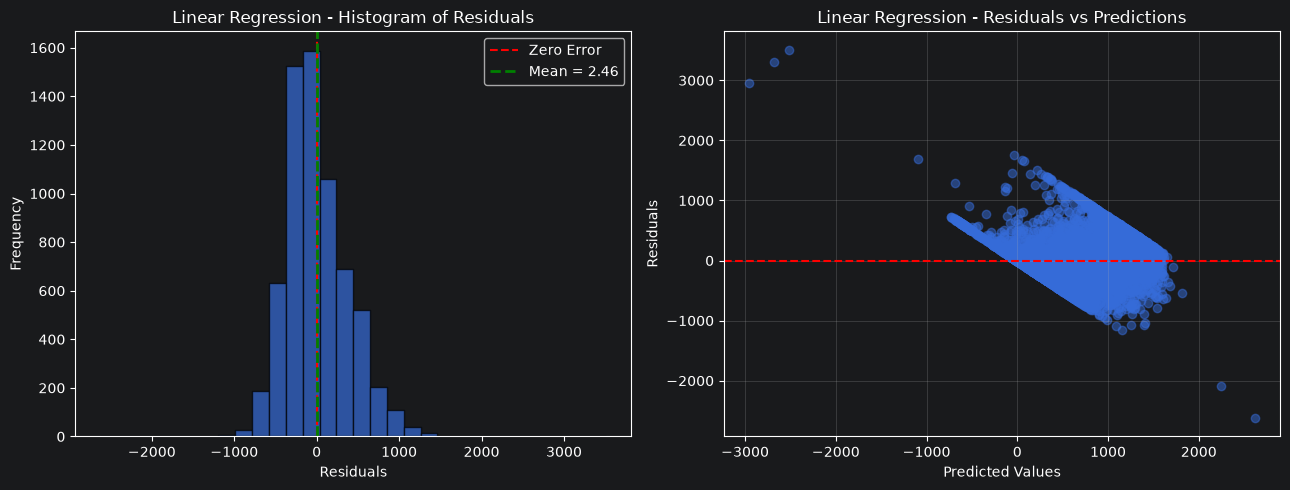

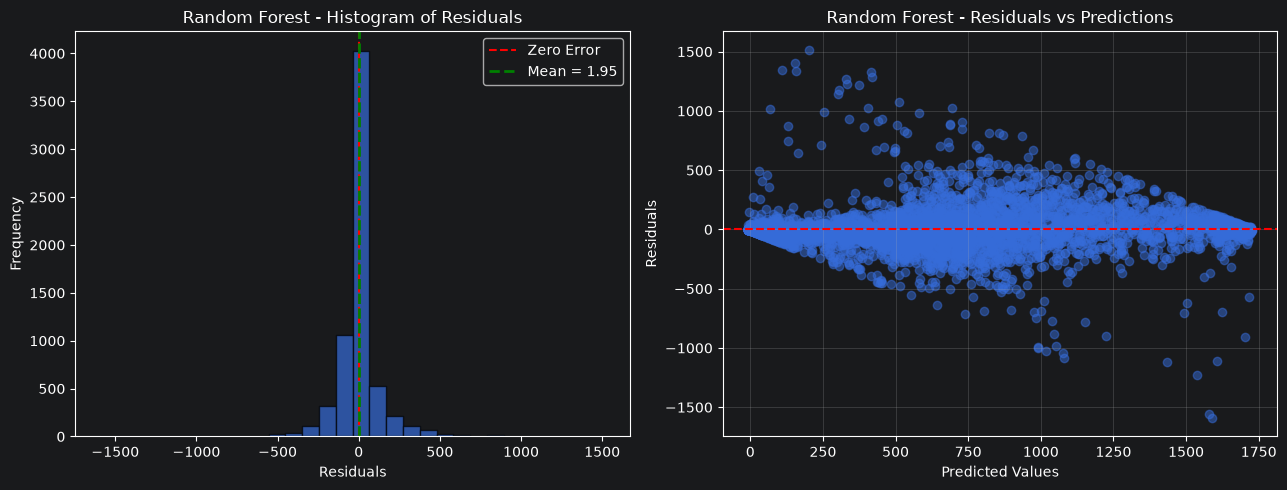

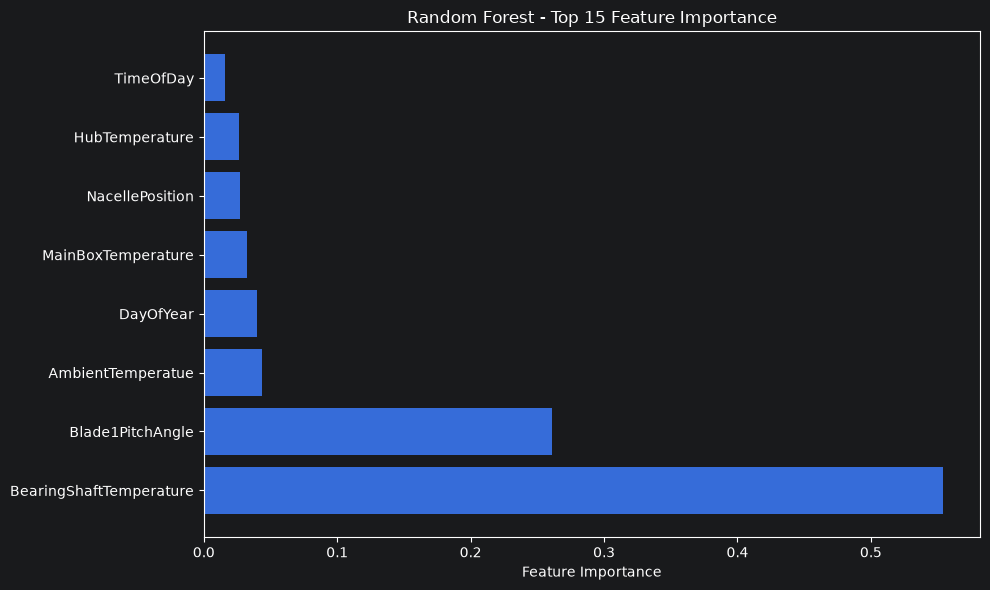

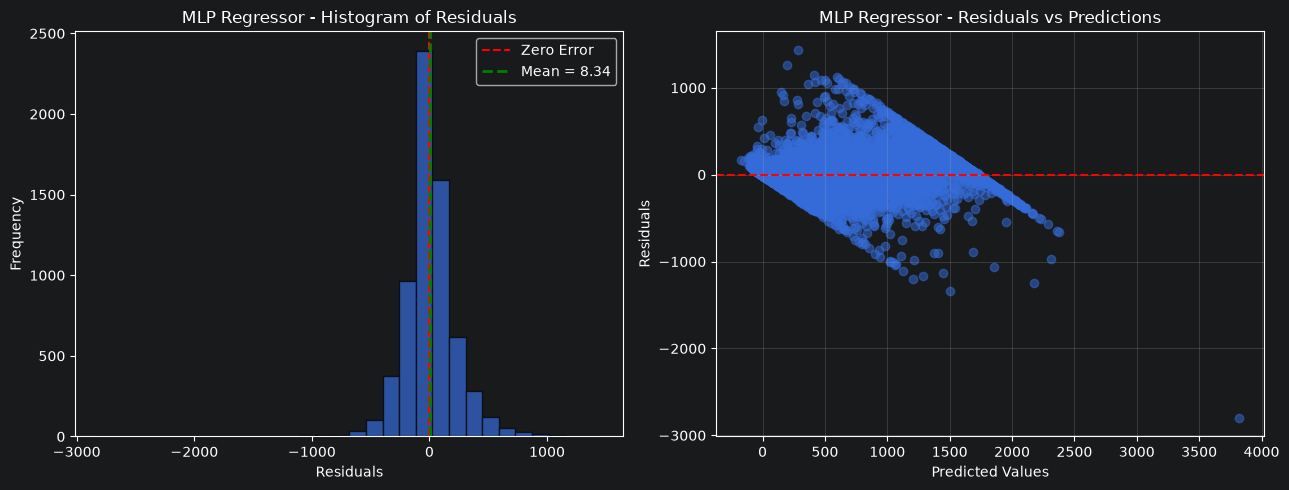


REGRESSION MODEL COMPARISON SUMMARY
            Model  Train Time (s)     Train MSE      Test MSE  Train MAE   Test MAE  Train R²  Test R²
Linear Regression        0.007156 146058.544763 145722.654160 293.557865 294.277559  0.593032 0.594111
    Random Forest        0.901070   3539.005216  23946.890148  28.818962  76.435677  0.990139 0.933299
    MLP Regressor        8.840821  47533.675831  50332.697391 147.502552 150.667570  0.867555 0.859806

Best Model (by Test R²): Random Forest with R² = 0.9333


In [7]:
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

# Store results for comparison
regression_results = []

# ============================================================
# 1. LINEAR REGRESSION
# ============================================================
start_time = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train, y_reg_train)
lr_train_time = time.time() - start_time

# Predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Metrics
lr_train_mse = mean_squared_error(y_reg_train, y_train_pred_lr)
lr_test_mse = mean_squared_error(y_reg_test, y_test_pred_lr)
lr_train_mae = mean_absolute_error(y_reg_train, y_train_pred_lr)
lr_test_mae = mean_absolute_error(y_reg_test, y_test_pred_lr)
lr_train_r2 = r2_score(y_reg_train, y_train_pred_lr)
lr_test_r2 = r2_score(y_reg_test, y_test_pred_lr)

regression_results.append({
    'Model': 'Linear Regression',
    'Train Time (s)': lr_train_time,
    'Train MSE': lr_train_mse,
    'Test MSE': lr_test_mse,
    'Train MAE': lr_train_mae,
    'Test MAE': lr_test_mae,
    'Train R²': lr_train_r2,
    'Test R²': lr_test_r2,
})

# Residuals visualization
residuals_lr = y_reg_test - y_test_pred_lr
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals_lr, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Linear Regression - Histogram of Residuals')
axes[0].axvline(0, color='red', linestyle='--', label='Zero Error')
axes[0].axvline(np.mean(residuals_lr), color='green', linestyle='dashed', linewidth=2,
                label=f"Mean = {np.mean(residuals_lr):.2f}")
axes[0].legend()

axes[1].scatter(y_test_pred_lr, residuals_lr, alpha=0.5)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Linear Regression - Residuals vs Predictions')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 2. RANDOM FOREST REGRESSOR
# ============================================================
start_time = time.time()
rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_reg_train)
rf_train_time = time.time() - start_time

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Metrics
rf_train_mse = mean_squared_error(y_reg_train, y_train_pred_rf)
rf_test_mse = mean_squared_error(y_reg_test, y_test_pred_rf)
rf_train_mae = mean_absolute_error(y_reg_train, y_train_pred_rf)
rf_test_mae = mean_absolute_error(y_reg_test, y_test_pred_rf)
rf_train_r2 = r2_score(y_reg_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_reg_test, y_test_pred_rf)

regression_results.append({
    'Model': 'Random Forest',
    'Train Time (s)': rf_train_time,
    'Train MSE': rf_train_mse,
    'Test MSE': rf_test_mse,
    'Train MAE': rf_train_mae,
    'Test MAE': rf_test_mae,
    'Train R²': rf_train_r2,
    'Test R²': rf_test_r2,
})

# Residuals visualization
residuals_rf = y_reg_test - y_test_pred_rf
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals_rf, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Random Forest - Histogram of Residuals')
axes[0].axvline(0, color='red', linestyle='--', label='Zero Error')
axes[0].axvline(np.mean(residuals_rf), color='green', linestyle='dashed', linewidth=2,
                label=f"Mean = {np.mean(residuals_rf):.2f}")
axes[0].legend()

axes[1].scatter(y_test_pred_rf, residuals_rf, alpha=0.5)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Random Forest - Residuals vs Predictions')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': final_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['Feature'].head(15), feature_importance_rf['Importance'].head(15))
plt.xlabel('Feature Importance')
plt.title('Random Forest - Top 15 Feature Importance')
plt.tight_layout()
plt.show()

# ============================================================
# 3. MLP REGRESSOR
# ============================================================

start_time = time.time()
mlp_model = MLPRegressor(hidden_layer_sizes=(20, 20), max_iter=1000, random_state=RANDOM_STATE, early_stopping=True, activation='relu', solver='adam')
mlp_model.fit(X_train, y_reg_train)
mlp_train_time = time.time() - start_time

# Predictions
y_train_pred_mlp = mlp_model.predict(X_train)
y_test_pred_mlp = mlp_model.predict(X_test)

# Metrics
mlp_train_mse = mean_squared_error(y_reg_train, y_train_pred_mlp)
mlp_test_mse = mean_squared_error(y_reg_test, y_test_pred_mlp)
mlp_train_mae = mean_absolute_error(y_reg_train, y_train_pred_mlp)
mlp_test_mae = mean_absolute_error(y_reg_test, y_test_pred_mlp)
mlp_train_r2 = r2_score(y_reg_train, y_train_pred_mlp)
mlp_test_r2 = r2_score(y_reg_test, y_test_pred_mlp)

regression_results.append({
    'Model': 'MLP Regressor',
    'Train Time (s)': mlp_train_time,
    'Train MSE': mlp_train_mse,
    'Test MSE': mlp_test_mse,
    'Train MAE': mlp_train_mae,
    'Test MAE': mlp_test_mae,
    'Train R²': mlp_train_r2,
    'Test R²': mlp_test_r2,
})

# Residuals visualization
residuals_mlp = y_reg_test - y_test_pred_mlp
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals_mlp, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('MLP Regressor - Histogram of Residuals')
axes[0].axvline(0, color='red', linestyle='--', label='Zero Error')
axes[0].axvline(np.mean(residuals_mlp), color='green', linestyle='dashed', linewidth=2,
                label=f"Mean = {np.mean(residuals_mlp):.2f}")
axes[0].legend()

axes[1].scatter(y_test_pred_mlp, residuals_mlp, alpha=0.5)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('MLP Regressor - Residuals vs Predictions')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY COMPARISON TABLE
# ============================================================
print("\n" + "=" * 60)
print("REGRESSION MODEL COMPARISON SUMMARY")
print("=" * 60)
regression_results_df = pd.DataFrame(regression_results)
print(regression_results_df.to_string(index=False))

# Identify best model by test R²
best_model_idx = regression_results_df['Test R²'].idxmax()
best_model = regression_results_df.loc[best_model_idx]
print(f"\nBest Model (by Test R²): {best_model['Model']} with R² = {best_model['Test R²']:.4f}")

### Regression Ranking

> `RandomForest` is distinctly better!

1. `LinearRegression` isn't particularly good as a default, but cross-terms might improve the quality. The agreement between `trainR2` and `testR2` indicates that the model is fitted, but not-overfitted - it's really underfitted because there are nonlinear relationships in this model.
2. `RandomForest` has an excellent performance on both the `train` and reasonable `test` set, indicating a quality model fit. Because the quality drops on the `test` set, the model is likely overfit to the training data with `n_estimators=100`.
3. Dropping to `n_estimators=5` cuts the training time by a factor of 15 (from 9s to to 0.6s) and only slightly reduces `testR2`.
4. Notice that the input features are heavily skewed, `BearingShaftTemperature` is another derived property with very strong correlation to `ActivePower`. `Blade1PitchAngle` is as well, but that makes sense. Without sufficient turbine blade pitch, you won't have rotation and therefore power.

## Classification Model Comparison
As requested, `LogisticRegression`, `MLPClassifier` are included. Because `RandomForest` tends to be an excellent model, I am including that model type as well. I expect `RandomForest` to perform the best and take far less time to train than `MLPClassifier`.

LOGISTIC REGRESSION CLASSIFIER


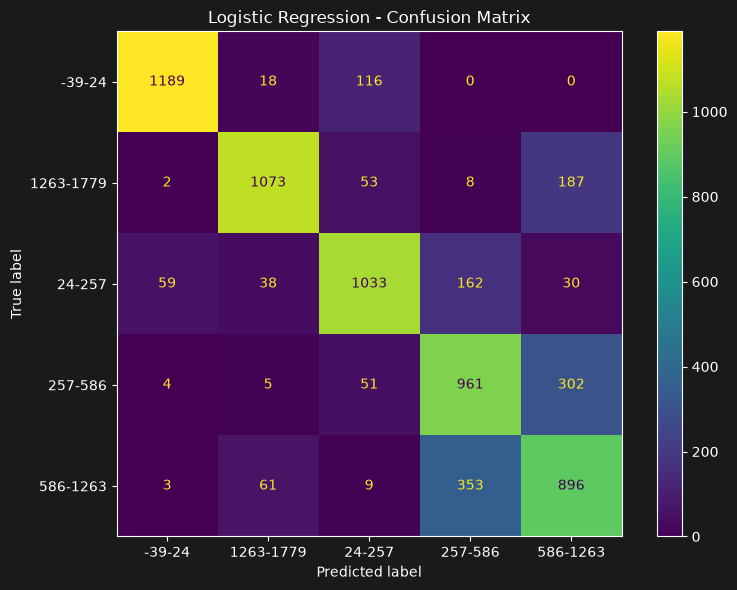


MLP CLASSIFIER


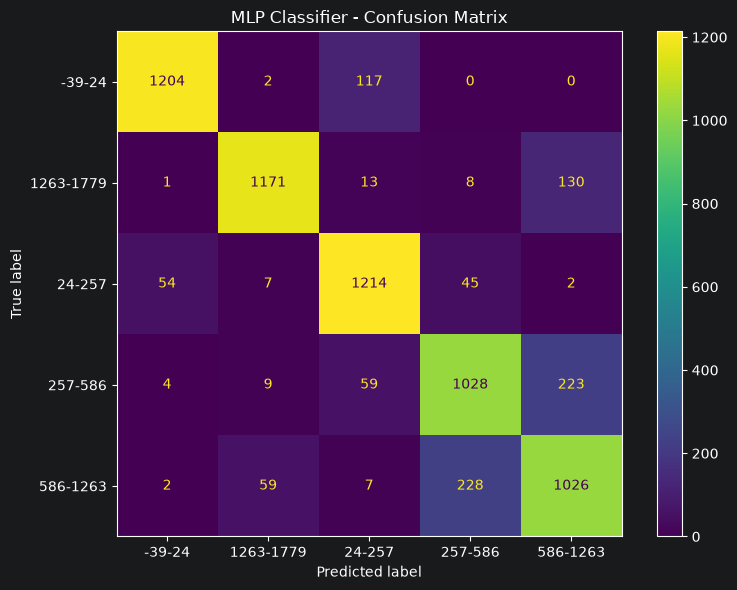

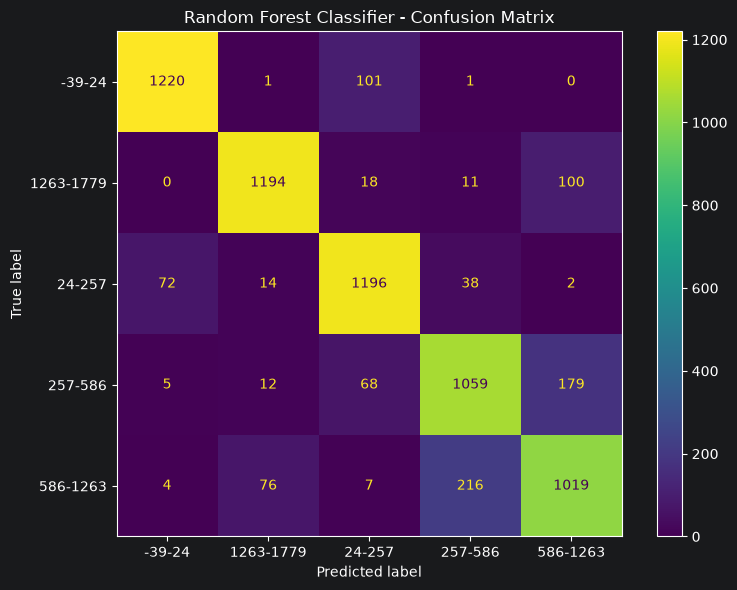


CLASSIFIER MODEL COMPARISON SUMMARY
                   Model  Train Time  Train Accuracy  Test Accuracy  Train F1  Test F1  Train Precision  Test Precision  Train Recall  Test Recall
     Logistic Regression    0.280201        0.770699       0.779072  0.774936 0.782607         0.782073        0.788647      0.770699     0.779072
          MLP Classifier    6.243986        0.859433       0.853319  0.860058 0.854092         0.861277        0.855885      0.859433     0.853319
Random Forest Classifier    0.096749        0.992212       0.860124  0.992209 0.860100         0.992215        0.860381      0.992212     0.860124

Best Model (by Test F1): Random Forest Classifier with F1 = 0.8601


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Store results for comparison
classifier_results = []

# ============================================================
# 1. LOGISTIC REGRESSION CLASSIFIER
# ============================================================
print("=" * 50)
print("LOGISTIC REGRESSION CLASSIFIER")
print("=" * 50)

start_time = time.time()
lr_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_clf.fit(X_train, y_cls_train)
lr_train_time = time.time() - start_time

# Predictions
y_train_pred_lr = lr_clf.predict(X_train)
y_test_pred_lr = lr_clf.predict(X_test)

# Metrics
lr_train_acc = accuracy_score(y_cls_train, y_train_pred_lr)
lr_test_acc = accuracy_score(y_cls_test, y_test_pred_lr)
lr_train_f1 = f1_score(y_cls_train, y_train_pred_lr, average='weighted')
lr_test_f1 = f1_score(y_cls_test, y_test_pred_lr, average='weighted')
lr_train_prec = precision_score(y_cls_train, y_train_pred_lr, average='weighted')
lr_test_prec = precision_score(y_cls_test, y_test_pred_lr, average='weighted')
lr_train_rec = recall_score(y_cls_train, y_train_pred_lr, average='weighted')
lr_test_rec = recall_score(y_cls_test, y_test_pred_lr, average='weighted')

classifier_results.append({
    'Model': 'Logistic Regression',
    'Train Time': lr_train_time,
    'Train Accuracy': lr_train_acc,
    'Test Accuracy': lr_test_acc,
    'Train F1': lr_train_f1,
    'Test F1': lr_test_f1,
    'Train Precision': lr_train_prec,
    'Test Precision': lr_test_prec,
    'Train Recall': lr_train_rec,
    'Test Recall': lr_test_rec,
})

# Confusion Matrix
cm_lr = confusion_matrix(y_cls_test, y_test_pred_lr)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_clf.classes_).plot(ax=ax)
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

# ============================================================
# 2. MLP CLASSIFIER
# ============================================================
print("\n" + "=" * 50)
print("MLP CLASSIFIER")
print("=" * 50)

start_time = time.time()
mlp_clf = MLPClassifier(hidden_layer_sizes=(20, 10), max_iter=1000, random_state=RANDOM_STATE)
mlp_clf.fit(X_train, y_cls_train)
mlp_train_time = time.time() - start_time

# Predictions
y_train_pred_mlp = mlp_clf.predict(X_train)
y_test_pred_mlp = mlp_clf.predict(X_test)

# Metrics
mlp_train_acc = accuracy_score(y_cls_train, y_train_pred_mlp)
mlp_test_acc = accuracy_score(y_cls_test, y_test_pred_mlp)
mlp_train_f1 = f1_score(y_cls_train, y_train_pred_mlp, average='weighted')
mlp_test_f1 = f1_score(y_cls_test, y_test_pred_mlp, average='weighted')
mlp_train_prec = precision_score(y_cls_train, y_train_pred_mlp, average='weighted')
mlp_test_prec = precision_score(y_cls_test, y_test_pred_mlp, average='weighted')
mlp_train_rec = recall_score(y_cls_train, y_train_pred_mlp, average='weighted')
mlp_test_rec = recall_score(y_cls_test, y_test_pred_mlp, average='weighted')

classifier_results.append({
    'Model': 'MLP Classifier',
    'Train Time': mlp_train_time,
    'Train Accuracy': mlp_train_acc,
    'Test Accuracy': mlp_test_acc,
    'Train F1': mlp_train_f1,
    'Test F1': mlp_test_f1,
    'Train Precision': mlp_train_prec,
    'Test Precision': mlp_test_prec,
    'Train Recall': mlp_train_rec,
    'Test Recall': mlp_test_rec,
})

# Confusion Matrix
cm_mlp = confusion_matrix(y_cls_test, y_test_pred_mlp)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=mlp_clf.classes_).plot(ax=ax)
ax.set_title('MLP Classifier - Confusion Matrix')
plt.tight_layout()
plt.show()

# ============================================================
# 3. RANDOM FOREST CLASSIFIER
# ============================================================
start_time = time.time()
# Starting w 10 similar to regression.
rf_clf = RandomForestClassifier(n_estimators=10, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train, y_cls_train)
rf_train_time = time.time() - start_time

# Predictions
y_train_pred_rf = rf_clf.predict(X_train)
y_test_pred_rf = rf_clf.predict(X_test)

# Metrics
rf_train_acc = accuracy_score(y_cls_train, y_train_pred_rf)
rf_test_acc = accuracy_score(y_cls_test, y_test_pred_rf)
rf_train_f1 = f1_score(y_cls_train, y_train_pred_rf, average='weighted')
rf_test_f1 = f1_score(y_cls_test, y_test_pred_rf, average='weighted')
rf_train_prec = precision_score(y_cls_train, y_train_pred_rf, average='weighted')
rf_test_prec = precision_score(y_cls_test, y_test_pred_rf, average='weighted')
rf_train_rec = recall_score(y_cls_train, y_train_pred_rf, average='weighted')
rf_test_rec = recall_score(y_cls_test, y_test_pred_rf, average='weighted')

classifier_results.append({
    'Model': 'Random Forest Classifier',
    'Train Time': rf_train_time,
    'Train Accuracy': rf_train_acc,
    'Test Accuracy': rf_test_acc,
    'Train F1': rf_train_f1,
    'Test F1': rf_test_f1,
    'Train Precision': rf_train_prec,
    'Test Precision': rf_test_prec,
    'Train Recall': rf_train_rec,
    'Test Recall': rf_test_rec,
})

# Confusion Matrix
cm_rf = confusion_matrix(y_cls_test, y_test_pred_rf)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_clf.classes_).plot(ax=ax)
ax.set_title('Random Forest Classifier - Confusion Matrix')
plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY COMPARISON TABLE
# ============================================================
print("\n" + "=" * 50)
print("CLASSIFIER MODEL COMPARISON SUMMARY")
print("=" * 50)
classifier_results_df = pd.DataFrame(classifier_results)
print(classifier_results_df.to_string(index=False))
# Identify best model by test F1
best_model_idx = classifier_results_df['Test F1'].idxmax()
best_model = classifier_results_df.loc[best_model_idx]
print(f"\nBest Model (by Test F1): {best_model['Model']} with F1 = {best_model['Test F1']:.4f}")

## Unsupervised + Supervised Pipeline

1. Cluster Training data using `KMeans` or another method.
2. For each cluster, build two specialized models: best regression, best classification
3. Evaluate hybrid system:
   1. Assign test sample to a cluster.
   2. Use cluster-specific local model to make the prediction
4. Compare results to non-clustered models.

CLUSTERING ANALYSIS - OPTIMIZING CLUSTER PARAMETERS

Testing KMeans with k from 2 to 11...
Testing HDBSCAN with min_samples from 5 to 20...
Testing GMM with k from 2 to 11...

KMeans:
  k=2: Silhouette=0.2321, Davies-Bouldin=1.6094, Calinski=8961.76, Time=1.554s
  k=5: Silhouette=0.2615, Davies-Bouldin=1.3919, Calinski=7229.26, Time=0.194s
  k=8: Silhouette=0.2742, Davies-Bouldin=1.3017, Calinski=6503.72, Time=0.309s
  k=11: Silhouette=0.2720, Davies-Bouldin=1.2289, Calinski=5998.60, Time=0.320s

HDBSCAN (varying min_samples):
  min_samples=5: n_clusters=2, noise=2, Silhouette=0.6856, Davies-Bouldin=0.8639, Calinski=189.15, Time=4.440s
  min_samples=8: n_clusters=2, noise=3, Silhouette=0.6907, Davies-Bouldin=1.0648, Calinski=196.36, Time=4.401s
  min_samples=11: n_clusters=2, noise=7, Silhouette=0.6748, Davies-Bouldin=1.1604, Calinski=204.67, Time=4.350s
  min_samples=14: n_clusters=3, noise=472, Silhouette=0.2878, Davies-Bouldin=1.9491, Calinski=832.71, Time=4.528s
  min_samples=17: n

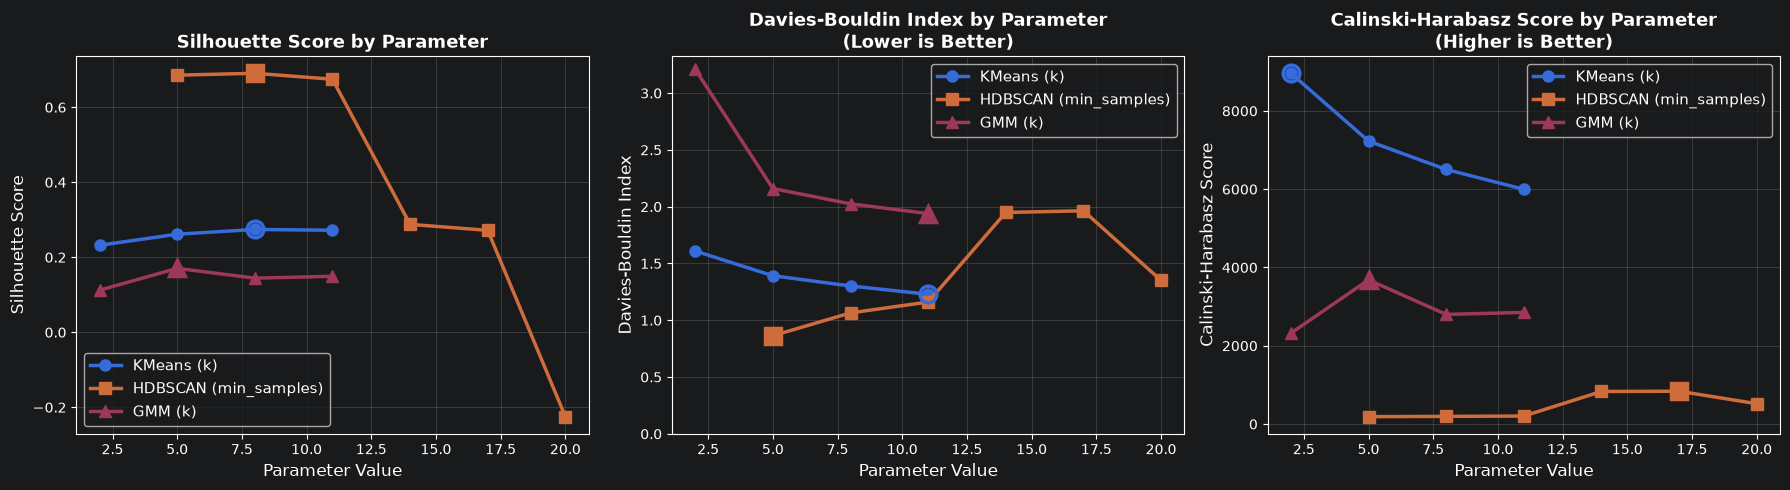


VISUALIZING OPTIMAL CLUSTERING RESULTS


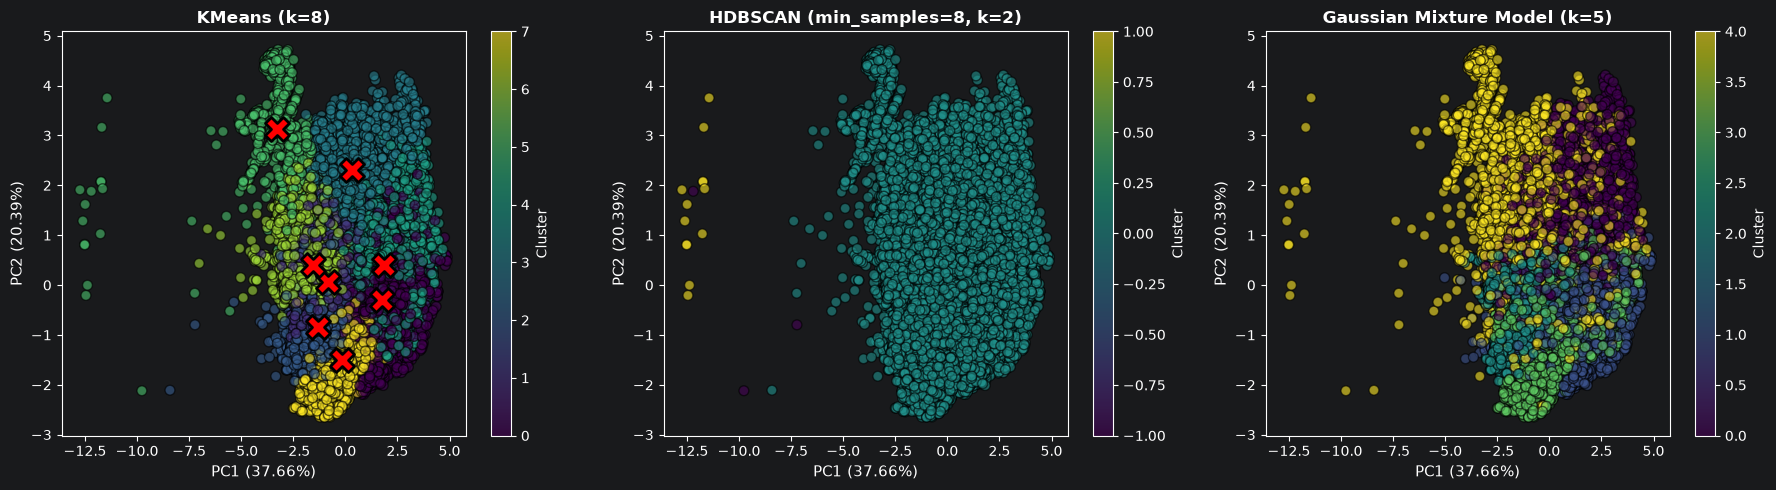


OPTIMAL CLUSTERING RESULTS SUMMARY
                Method     Parameter  Silhouette  Davies-Bouldin  Calinski-Harabasz  Time (s)
                KMeans           k=8    0.274203        1.301677        6503.718417  0.308967
               HDBSCAN min_samples=8    0.690688        1.064782         196.357886  4.401016
Gaussian Mixture Model           k=5    0.170479        2.159551        3683.856770  4.751924


In [9]:
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CLUSTERING ANALYSIS: KMeans vs HDBSCAN vs Gaussian Mixture
# ============================================================

print("=" * 70)
print("CLUSTERING ANALYSIS - OPTIMIZING CLUSTER PARAMETERS")
print("=" * 70)

# Range of parameters to test
K_range = range(2, 12,3)
hdbscan_min_samples_range = range(5, 21, 3)  # min_samples parameter for HDBSCAN

# Store results for each method
results = {
    'KMeans': {'k': [], 'silhouette': [], 'davies_bouldin': [], 'calinski': [], 'time': []},
    'HDBSCAN': {'params': [], 'n_clusters': [], 'silhouette': [], 'davies_bouldin': [], 'calinski': [], 'time': []},
    'GMM': {'k': [], 'silhouette': [], 'davies_bouldin': [], 'calinski': [], 'time': []},
}

print(f"\nTesting KMeans with k from {K_range.start} to {K_range.stop - 1}...")
print(f"Testing HDBSCAN with min_samples from {hdbscan_min_samples_range.start} to {hdbscan_min_samples_range.stop - 1}...")
print(f"Testing GMM with k from {K_range.start} to {K_range.stop - 1}...")

# ============================================================
# KMEANS ACROSS RANGE OF K
# ============================================================
print("\nKMeans:")
for k in K_range:
    start_time = time.time()
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_train)
    train_time = time.time() - start_time
    
    silhouette = silhouette_score(X_train, labels)
    davies_bouldin = davies_bouldin_score(X_train, labels)
    calinski = calinski_harabasz_score(X_train, labels)
    
    results['KMeans']['k'].append(k)
    results['KMeans']['silhouette'].append(silhouette)
    results['KMeans']['davies_bouldin'].append(davies_bouldin)
    results['KMeans']['calinski'].append(calinski)
    results['KMeans']['time'].append(train_time)
    
    print(f"  k={k}: Silhouette={silhouette:.4f}, Davies-Bouldin={davies_bouldin:.4f}, Calinski={calinski:.2f}, Time={train_time:.3f}s")

# ============================================================
# HDBSCAN ACROSS RANGE OF MIN_SAMPLES
# ============================================================
print("\nHDBSCAN (varying min_samples):")
for min_samples in hdbscan_min_samples_range:
    start_time = time.time()
    hdbscan = HDBSCAN(min_samples=min_samples, min_cluster_size=10)
    labels = hdbscan.fit_predict(X_train)
    train_time = time.time() - start_time
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    if n_clusters > 1 and n_noise < len(labels) * 0.5:  # Only evaluate if reasonable clustering
        silhouette = silhouette_score(X_train, labels)
        davies_bouldin = davies_bouldin_score(X_train, labels)
        calinski = calinski_harabasz_score(X_train, labels)
    else:
        silhouette = -1.0
        davies_bouldin = float('inf')
        calinski = 0.0
    
    results['HDBSCAN']['params'].append(min_samples)
    results['HDBSCAN']['n_clusters'].append(n_clusters)
    results['HDBSCAN']['silhouette'].append(silhouette)
    results['HDBSCAN']['davies_bouldin'].append(davies_bouldin)
    results['HDBSCAN']['calinski'].append(calinski)
    results['HDBSCAN']['time'].append(train_time)
    
    print(f"  min_samples={min_samples}: n_clusters={n_clusters}, noise={n_noise}, Silhouette={silhouette:.4f}, Davies-Bouldin={davies_bouldin:.4f}, Calinski={calinski:.2f}, Time={train_time:.3f}s")

# ============================================================
# GAUSSIAN MIXTURE MODEL ACROSS RANGE OF K
# ============================================================
print("\nGaussian Mixture Model:")
for k in K_range:
    start_time = time.time()
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=10)
    labels = gmm.fit_predict(X_train)
    train_time = time.time() - start_time
    
    silhouette = silhouette_score(X_train, labels)
    davies_bouldin = davies_bouldin_score(X_train, labels)
    calinski = calinski_harabasz_score(X_train, labels)
    
    results['GMM']['k'].append(k)
    results['GMM']['silhouette'].append(silhouette)
    results['GMM']['davies_bouldin'].append(davies_bouldin)
    results['GMM']['calinski'].append(calinski)
    results['GMM']['time'].append(train_time)
    
    print(f"  k={k}: Silhouette={silhouette:.4f}, Davies-Bouldin={davies_bouldin:.4f}, Calinski={calinski:.2f}, Time={train_time:.3f}s")

# ============================================================
# FIND OPTIMAL FOR EACH METHOD
# ============================================================
print("\n" + "=" * 70)
print("OPTIMAL PARAMETERS (BY SILHOUETTE SCORE)")
print("=" * 70)

# KMeans optimal
best_idx = np.argmax(results['KMeans']['silhouette'])
optimal_kmeans_k = results['KMeans']['k'][best_idx]
print(f"\nKMeans:")
print(f"  Optimal k: {optimal_kmeans_k}")
print(f"  Silhouette Score: {results['KMeans']['silhouette'][best_idx]:.4f}")
print(f"  Davies-Bouldin Index: {results['KMeans']['davies_bouldin'][best_idx]:.4f}")
print(f"  Calinski-Harabasz Score: {results['KMeans']['calinski'][best_idx]:.2f}")

# HDBSCAN optimal (filter out invalid clusterings)
valid_hdbscan = [(i, s) for i, s in enumerate(results['HDBSCAN']['silhouette']) if s >= 0]
if valid_hdbscan:
    best_idx = max(valid_hdbscan, key=lambda x: x[1])[0]
    optimal_hdbscan_params = results['HDBSCAN']['params'][best_idx]
    print(f"\nHDBSCAN:")
    print(f"  Optimal min_samples: {optimal_hdbscan_params}")
    print(f"  Number of Clusters: {results['HDBSCAN']['n_clusters'][best_idx]}")
    print(f"  Silhouette Score: {results['HDBSCAN']['silhouette'][best_idx]:.4f}")
    print(f"  Davies-Bouldin Index: {results['HDBSCAN']['davies_bouldin'][best_idx]:.4f}")
    print(f"  Calinski-Harabasz Score: {results['HDBSCAN']['calinski'][best_idx]:.2f}")
else:
    print(f"\nHDBSCAN: No valid clustering found in parameter range")
    optimal_hdbscan_params = None
    best_idx = 0

# GMM optimal
best_idx = np.argmax(results['GMM']['silhouette'])
optimal_gmm_k = results['GMM']['k'][best_idx]
print(f"\nGaussian Mixture Model:")
print(f"  Optimal k: {optimal_gmm_k}")
print(f"  Silhouette Score: {results['GMM']['silhouette'][best_idx]:.4f}")
print(f"  Davies-Bouldin Index: {results['GMM']['davies_bouldin'][best_idx]:.4f}")
print(f"  Calinski-Harabasz Score: {results['GMM']['calinski'][best_idx]:.2f}")

# ============================================================
# PLOT METRICS OVERLAID
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette Score plot
axes[0].plot(results['KMeans']['k'], results['KMeans']['silhouette'], 'o-', linewidth=2.5, markersize=8, label='KMeans (k)')
axes[0].plot(results['HDBSCAN']['params'], results['HDBSCAN']['silhouette'], 's-', linewidth=2.5, markersize=8, label='HDBSCAN (min_samples)')
axes[0].plot(results['GMM']['k'], results['GMM']['silhouette'], '^-', linewidth=2.5, markersize=8, label='GMM (k)')
axes[0].set_xlabel('Parameter Value', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score by Parameter', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

# Mark optimal points
best_idx = np.argmax(results['KMeans']['silhouette'])
axes[0].plot(results['KMeans']['k'][best_idx], results['KMeans']['silhouette'][best_idx], 'o', markersize=12, markerfacecolor='none', markeredgewidth=2.5, color='C0')

valid_hdbscan = [(i, s) for i, s in enumerate(results['HDBSCAN']['silhouette']) if s >= 0]
if valid_hdbscan:
    best_idx = max(valid_hdbscan, key=lambda x: x[1])[0]
    axes[0].plot(results['HDBSCAN']['params'][best_idx], results['HDBSCAN']['silhouette'][best_idx], 's', markersize=12, markerfacecolor='none', markeredgewidth=2.5, color='C1')

best_idx = np.argmax(results['GMM']['silhouette'])
axes[0].plot(results['GMM']['k'][best_idx], results['GMM']['silhouette'][best_idx], '^', markersize=12, markerfacecolor='none', markeredgewidth=2.5, color='C2')

# Davies-Bouldin Index plot (lower is better)
axes[1].plot(results['KMeans']['k'], results['KMeans']['davies_bouldin'], 'o-', linewidth=2.5, markersize=8, label='KMeans (k)')
axes[1].plot(results['HDBSCAN']['params'], results['HDBSCAN']['davies_bouldin'], 's-', linewidth=2.5, markersize=8, label='HDBSCAN (min_samples)')
axes[1].plot(results['GMM']['k'], results['GMM']['davies_bouldin'], '^-', linewidth=2.5, markersize=8, label='GMM (k)')
axes[1].set_xlabel('Parameter Value', fontsize=12)
axes[1].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1].set_title('Davies-Bouldin Index by Parameter\n(Lower is Better)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].set_ylim(bottom=0)

# Mark optimal points
best_idx = np.argmin([x for x in results['KMeans']['davies_bouldin']])
axes[1].plot(results['KMeans']['k'][best_idx], results['KMeans']['davies_bouldin'][best_idx], 'o', markersize=12, markerfacecolor='none', markeredgewidth=2.5, color='C0')

valid_hdbscan_db = [(i, x) for i, x in enumerate(results['HDBSCAN']['davies_bouldin']) if x != float('inf') and x > 0]
if valid_hdbscan_db:
    best_idx = min(valid_hdbscan_db, key=lambda x: x[1])[0]
    axes[1].plot(results['HDBSCAN']['params'][best_idx], results['HDBSCAN']['davies_bouldin'][best_idx], 's', markersize=12, markerfacecolor='none', markeredgewidth=2.5, color='C1')

best_idx = np.argmin([x for x in results['GMM']['davies_bouldin']])
axes[1].plot(results['GMM']['k'][best_idx], results['GMM']['davies_bouldin'][best_idx], '^', markersize=12, markerfacecolor='none', markeredgewidth=2.5, color='C2')

# Calinski-Harabasz Score plot (higher is better)
axes[2].plot(results['KMeans']['k'], results['KMeans']['calinski'], 'o-', linewidth=2.5, markersize=8, label='KMeans (k)')
axes[2].plot(results['HDBSCAN']['params'], results['HDBSCAN']['calinski'], 's-', linewidth=2.5, markersize=8, label='HDBSCAN (min_samples)')
axes[2].plot(results['GMM']['k'], results['GMM']['calinski'], '^-', linewidth=2.5, markersize=8, label='GMM (k)')
axes[2].set_xlabel('Parameter Value', fontsize=12)
axes[2].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[2].set_title('Calinski-Harabasz Score by Parameter\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=11)

# Mark optimal points
best_idx = np.argmax(results['KMeans']['calinski'])
axes[2].plot(results['KMeans']['k'][best_idx], results['KMeans']['calinski'][best_idx], 'o', markersize=12, markerfacecolor='none', markeredgewidth=2.5, color='C0')

valid_hdbscan_ch = [(i, x) for i, x in enumerate(results['HDBSCAN']['calinski']) if x > 0]
if valid_hdbscan_ch:
    best_idx = max(valid_hdbscan_ch, key=lambda x: x[1])[0]
    axes[2].plot(results['HDBSCAN']['params'][best_idx], results['HDBSCAN']['calinski'][best_idx], 's', markersize=12, markerfacecolor='none', markeredgewidth=2.5, color='C1')

best_idx = np.argmax(results['GMM']['calinski'])
axes[2].plot(results['GMM']['k'][best_idx], results['GMM']['calinski'][best_idx], '^', markersize=12, markerfacecolor='none', markeredgewidth=2.5, color='C2')

plt.tight_layout()
plt.show()

# ============================================================
# TRAIN OPTIMAL MODELS AND VISUALIZE
# ============================================================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

print("\n" + "=" * 70)
print("VISUALIZING OPTIMAL CLUSTERING RESULTS")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KMeans with optimal k
kmeans = KMeans(n_clusters=optimal_kmeans_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_train)

scatter = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=kmeans_labels, 
                         cmap='viridis', s=50, alpha=0.6, edgecolors='k')
axes[0].scatter(pca.transform(kmeans.cluster_centers_)[:, 0], 
               pca.transform(kmeans.cluster_centers_)[:, 1],
               c='red', marker='X', s=300, edgecolors='black', linewidths=2)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
axes[0].set_title(f'KMeans (k={optimal_kmeans_k})', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# HDBSCAN with optimal params
if optimal_hdbscan_params is not None:
    hdbscan = HDBSCAN(min_samples=optimal_hdbscan_params, min_cluster_size=10)
    hdbscan_labels = hdbscan.fit_predict(X_train)
    n_clusters_hdbscan = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
    
    scatter = axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=hdbscan_labels, 
                             cmap='viridis', s=50, alpha=0.6, edgecolors='k')
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
    axes[1].set_title(f'HDBSCAN (min_samples={optimal_hdbscan_params}, k={n_clusters_hdbscan})', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=axes[1], label='Cluster')
else:
    axes[1].text(0.5, 0.5, 'No valid HDBSCAN\nclustering found', 
                ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
    axes[1].set_title('HDBSCAN', fontsize=12, fontweight='bold')

# GMM with optimal k
gmm = GaussianMixture(n_components=optimal_gmm_k, random_state=RANDOM_STATE, n_init=10)
gmm_labels = gmm.fit_predict(X_train)

scatter = axes[2].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=gmm_labels, 
                         cmap='viridis', s=50, alpha=0.6, edgecolors='k')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
axes[2].set_title(f'Gaussian Mixture Model (k={optimal_gmm_k})', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[2], label='Cluster')

plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "=" * 70)
print("OPTIMAL CLUSTERING RESULTS SUMMARY")
print("=" * 70)

summary_data = []

best_idx = np.argmax(results['KMeans']['silhouette'])
summary_data.append({
    'Method': 'KMeans',
    'Parameter': f'k={optimal_kmeans_k}',
    'Silhouette': results['KMeans']['silhouette'][best_idx],
    'Davies-Bouldin': results['KMeans']['davies_bouldin'][best_idx],
    'Calinski-Harabasz': results['KMeans']['calinski'][best_idx],
    'Time (s)': results['KMeans']['time'][best_idx],
})

if optimal_hdbscan_params is not None:
    best_idx = [i for i, s in enumerate(results['HDBSCAN']['silhouette']) if s >= 0]
    best_idx = max(best_idx, key=lambda i: results['HDBSCAN']['silhouette'][i]) if best_idx else 0
    summary_data.append({
        'Method': 'HDBSCAN',
        'Parameter': f'min_samples={optimal_hdbscan_params}',
        'Silhouette': results['HDBSCAN']['silhouette'][best_idx],
        'Davies-Bouldin': results['HDBSCAN']['davies_bouldin'][best_idx],
        'Calinski-Harabasz': results['HDBSCAN']['calinski'][best_idx],
        'Time (s)': results['HDBSCAN']['time'][best_idx],
    })

best_idx = np.argmax(results['GMM']['silhouette'])
summary_data.append({
    'Method': 'Gaussian Mixture Model',
    'Parameter': f'k={optimal_gmm_k}',
    'Silhouette': results['GMM']['silhouette'][best_idx],
    'Davies-Bouldin': results['GMM']['davies_bouldin'][best_idx],
    'Calinski-Harabasz': results['GMM']['calinski'][best_idx],
    'Time (s)': results['GMM']['time'][best_idx],
})

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

### Clustering Notes
1. `KMeans` doesn't cluster well
2. `SpectralClustering` takes 60+ sec per iteration, so was excluded.
3. `GaussianMixture` fits, but shows that all the data basically associates to all clusters
4. The PCA plot shows that the data is relatively uniform, so it is unlikely that there are actual clusters in the data.
5. Below is an operation using my own performant implementation of IVAT that can handle 33K data points.

## Conclusions & Justification
These are the questions from the assignment with my answers interspersed.
1. Which models performed best and why?
2. Which features mattered?
3. Did clustering help?
4. What did you learn from your dataset?
5. What would you do next with more time/data?

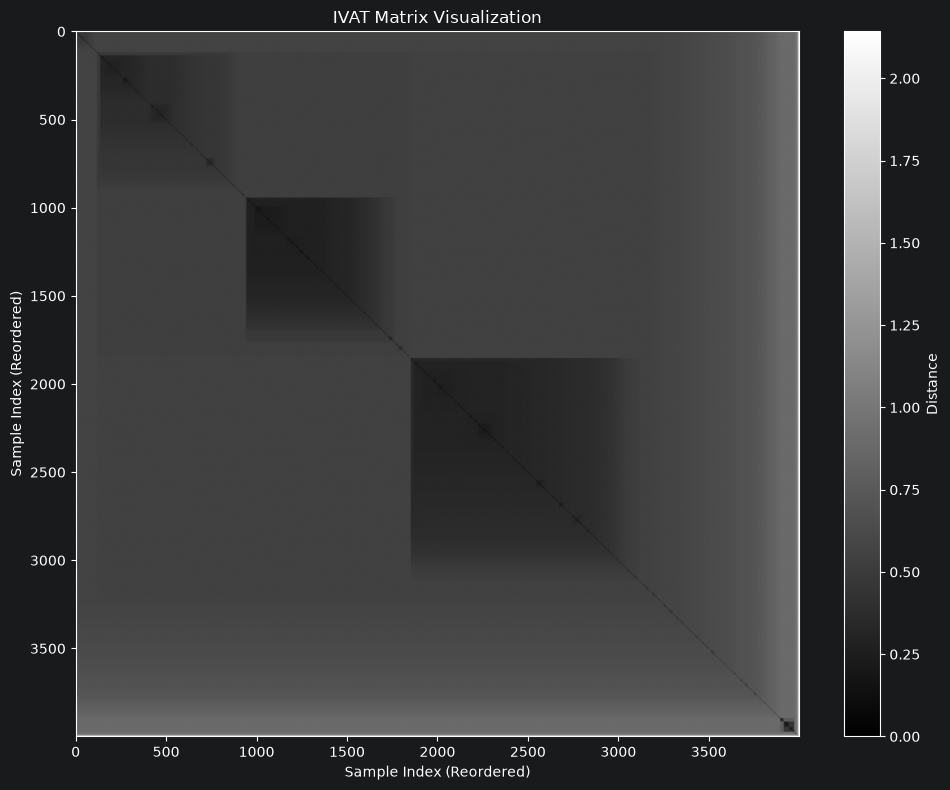

In [12]:
# You can install this way, but I use it locally !pip install git+https://github.com/fundthmcalculus/clustering
try:
    import tribbleclustering
except ModuleNotFoundError:
    !pip install git+https://github.com/fundthmcalculus/clustering

from tribbleclustering import compute_ivat, pairwise_distances

# Training vs Test data doesn't matter here - and the dynamic range isn't great, so log-scale it.
# Because we don't have the Cython kernel on jupyter (sads), this takes 3-ish minutes, so let's just do a subsample.
X_vat = X_train[np.random.choice(X_train.shape[0], 4000, replace=False)]
pdists = pairwise_distances(X_vat.astype(np.float32))
# Default range is 0-7, with a lot less than 1, so let's log-scale it
# log1p so that the 0 distance still maps to 0 post-transform.
pdists =np.log1p(pdists)
ivat, _, _ = compute_ivat(pdists, inplace=True)
plt.figure(figsize=(10, 8))
plt.imshow(ivat, cmap='gray', aspect='auto')
plt.colorbar(label='log2 Distance')
plt.title('IVAT Matrix Visualization')
plt.xlabel('Sample Index (Reordered)')
plt.ylabel('Sample Index (Reordered)')
plt.tight_layout()
plt.show()

As can be seen above, the close-cluster blocks aren't super dark, indicating that there is not a super-strong clustering affinity in this dataset. As a result, the clustering approach is never that great, and the unsupervised+supervised approach likely will not improve over the regular regression model. For simplicity and performance, I have chosen `k=3` KMeans as the best clustering method because it's close in silhouette score and there are 3 dark blocks in the IVAT image.

SUBCLUSTER ANALYSIS - KMEANS K=2 WITH RANDOMFOREST MODELS

Subcluster Distribution (Training Set):
  Subcluster 0: 10277 samples (38.9%)
  Subcluster 1: 3491 samples (13.2%)
  Subcluster 2: 12682 samples (47.9%)


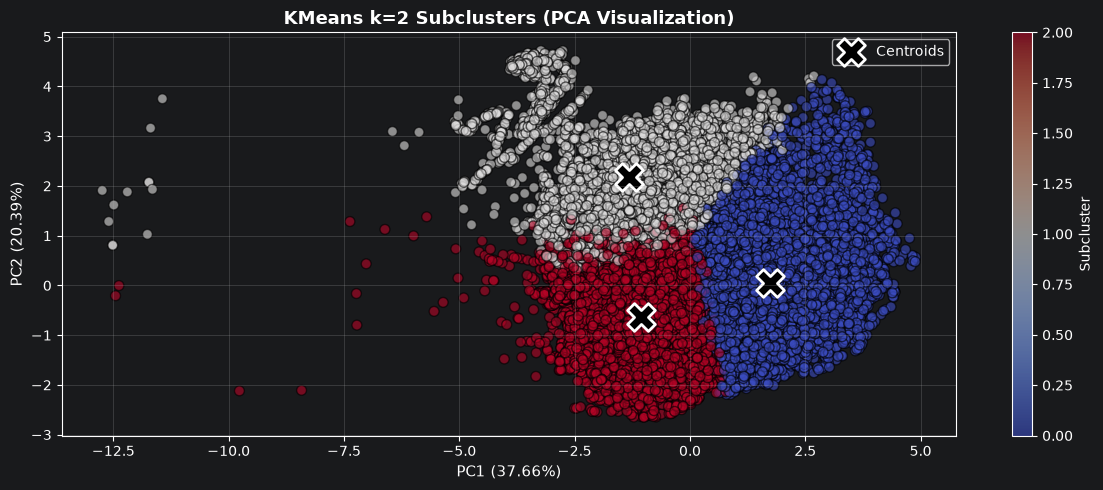


SUBCLUSTER 0 ANALYSIS

Subcluster 0 Data Distribution:
  Training samples: 10277
  Test samples: 2606

--- Classification Model (RandomForest) ---
Training Time: 0.191 seconds
Train Accuracy: 1.0000 | Test Accuracy: 0.8503
Train F1-Score: 1.0000 | Test F1-Score: 0.8501
Train Precision: 1.0000 | Test Precision: 0.8515
Train Recall: 1.0000 | Test Recall: 0.8503

Top 5 Important Features for Classification:
  Blade1PitchAngle: 0.3587
  BearingShaftTemperature: 0.1894
  AmbientTemperatue: 0.0924
  DayOfYear: 0.0919
  NacellePosition: 0.0789

--- Regression Model (RandomForest) ---
Training Time: 0.298 seconds
Train MSE: 4114.5388 | Test MSE: 29008.2841
Train MAE: 35.1153 | Test MAE: 94.4776
Train R²: 0.9903 | Test R²: 0.9319

Top 5 Important Features for Regression:
  BearingShaftTemperature: 0.5100
  Blade1PitchAngle: 0.2738
  AmbientTemperatue: 0.0538
  NacellePosition: 0.0474
  DayOfYear: 0.0364


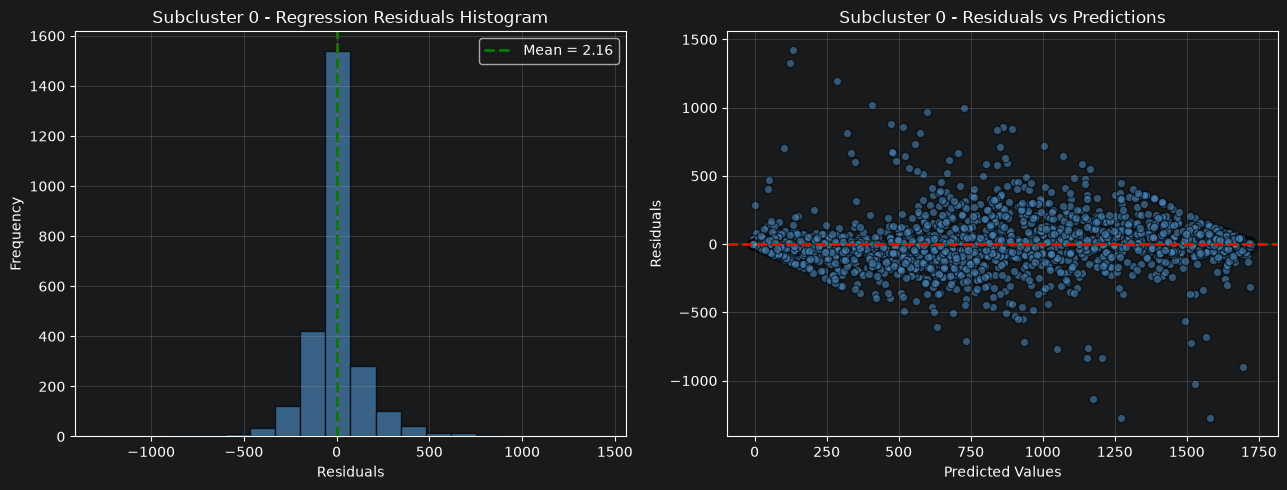


SUBCLUSTER 1 ANALYSIS

Subcluster 1 Data Distribution:
  Training samples: 3491
  Test samples: 868

--- Classification Model (RandomForest) ---
Training Time: 0.119 seconds
Train Accuracy: 1.0000 | Test Accuracy: 0.9827
Train F1-Score: 1.0000 | Test F1-Score: 0.9770
Train Precision: 1.0000 | Test Precision: 0.9725
Train Recall: 1.0000 | Test Recall: 0.9827

Top 5 Important Features for Classification:
  Blade1PitchAngle: 0.3040
  BearingShaftTemperature: 0.1250
  HubTemperature: 0.1108
  MainBoxTemperature: 0.1027
  AmbientTemperatue: 0.1023

--- Regression Model (RandomForest) ---
Training Time: 0.138 seconds
Train MSE: 288.5260 | Test MSE: 1635.7650
Train MAE: 1.6381 | Test MAE: 4.7777
Train R²: 0.8806 | Test R²: 0.4683

Top 5 Important Features for Regression:
  Blade1PitchAngle: 0.5957
  NacellePosition: 0.0924
  MainBoxTemperature: 0.0765
  TimeOfDay: 0.0612
  AmbientTemperatue: 0.0462


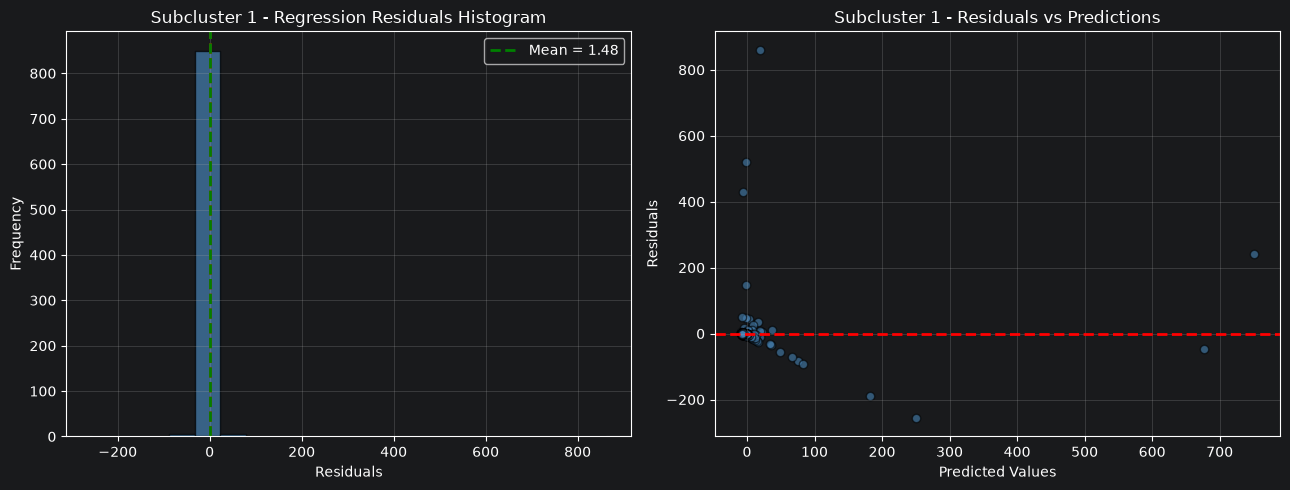


SUBCLUSTER 2 ANALYSIS

Subcluster 2 Data Distribution:
  Training samples: 12682
  Test samples: 3139

--- Classification Model (RandomForest) ---
Training Time: 0.263 seconds
Train Accuracy: 1.0000 | Test Accuracy: 0.8525
Train F1-Score: 1.0000 | Test F1-Score: 0.8512
Train Precision: 1.0000 | Test Precision: 0.8528
Train Recall: 1.0000 | Test Recall: 0.8525

Top 5 Important Features for Classification:
  Blade1PitchAngle: 0.4264
  BearingShaftTemperature: 0.1685
  TimeOfDay: 0.0754
  AmbientTemperatue: 0.0685
  NacellePosition: 0.0684

--- Regression Model (RandomForest) ---
Training Time: 0.393 seconds
Train MSE: 3923.6410 | Test MSE: 27024.4348
Train MAE: 31.5383 | Test MAE: 82.9351
Train R²: 0.9808 | Test R²: 0.8678

Top 5 Important Features for Regression:
  BearingShaftTemperature: 0.4056
  Blade1PitchAngle: 0.3168
  NacellePosition: 0.0950
  DayOfYear: 0.0443
  TimeOfDay: 0.0402


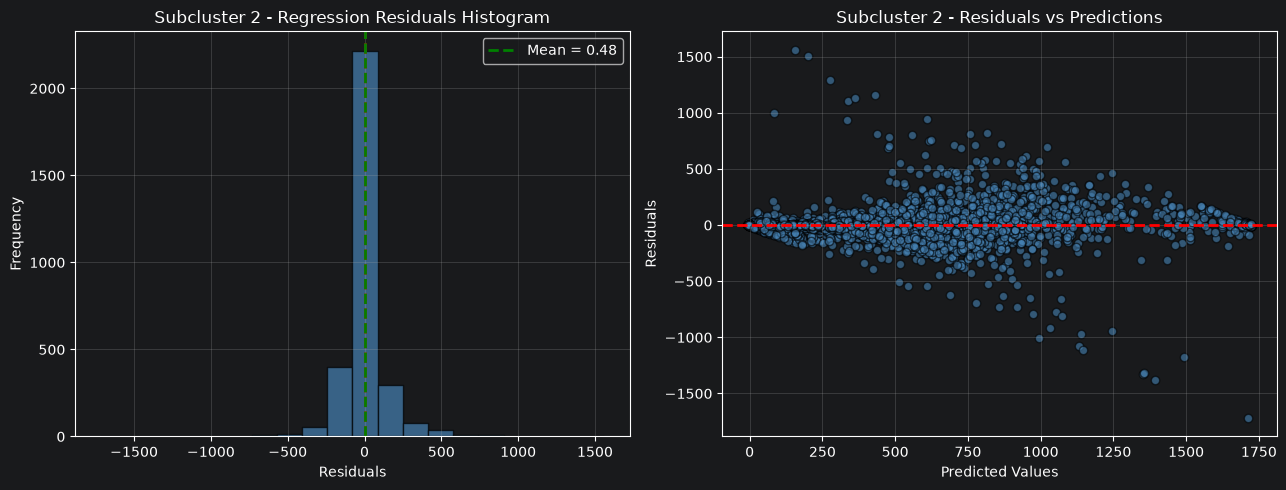


SUBCLUSTER MODELS - SUMMARY COMPARISON

--- Classification Performance ---
 Subcluster  Train_Size  Test_Size  Clf_Train_Acc  Clf_Test_Acc  Clf_Train_F1  Clf_Test_F1  Clf_Time
          0       10277       2606            1.0      0.850345           1.0     0.850127  0.191340
          1        3491        868            1.0      0.982719           1.0     0.977014  0.118729
          2       12682       3139            1.0      0.852501           1.0     0.851155  0.262656

--- Regression Performance ---
 Subcluster  Reg_Train_MSE  Reg_Test_MSE  Reg_Train_MAE  Reg_Test_MAE  Reg_Train_R2  Reg_Test_R2  Reg_Time
          0    4114.538777  29008.284147      35.115272     94.477627      0.990325     0.931863  0.298299
          1     288.526004   1635.764977       1.638091      4.777710      0.880593     0.468327  0.138353
          2    3923.640983  27024.434829      31.538265     82.935133      0.980835     0.867819  0.392845

KEY INSIGHTS

Best Classification Cluster: Subcluster 1
Bes

In [16]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# SUBCLUSTER ANALYSIS: KMeans k=2 WITH SPECIALIZED MODELS
# ============================================================

print("=" * 70)
print("SUBCLUSTER ANALYSIS - KMEANS K=2 WITH RANDOMFOREST MODELS")
print("=" * 70)

picked_k = 3 # Set from IVAT image above.

# Train KMeans to split data into subclusters
kmeans_picked = KMeans(n_clusters=picked_k, random_state=RANDOM_STATE, n_init=10)
subcluster_labels_train = kmeans_picked.fit_predict(X_train)
subcluster_labels_test = kmeans_picked.predict(X_test)

print(f"\nSubcluster Distribution (Training Set):")
unique, counts = np.unique(subcluster_labels_train, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Subcluster {cluster}: {count} samples ({count/len(X_train)*100:.1f}%)")

# Visualize the two subclusters (PCA)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

plt.figure(figsize=(12, 5))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=subcluster_labels_train, 
                     cmap='coolwarm', s=50, alpha=0.6, edgecolors='k')
plt.scatter(pca.transform(kmeans_picked.cluster_centers_)[:, 0],
            pca.transform(kmeans_picked.cluster_centers_)[:, 1],
            c='black', marker='X', s=400, edgecolors='white', linewidths=2,
            label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
plt.title('KMeans k=2 Subclusters (PCA Visualization)', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Subcluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# TRAIN AND EVALUATE MODELS FOR EACH SUBCLUSTER
# ============================================================

subcluster_results = []

for cluster_id in unique:
    print("\n" + "=" * 70)
    print(f"SUBCLUSTER {cluster_id} ANALYSIS")
    print("=" * 70)
    
    # Get data for this subcluster
    train_mask = subcluster_labels_train == cluster_id
    test_mask = subcluster_labels_test == cluster_id
    
    X_train_cluster = X_train[train_mask]
    X_test_cluster = X_test[test_mask]
    y_reg_train_cluster = y_reg_train[train_mask]
    y_reg_test_cluster = y_reg_test[test_mask]
    y_cls_train_cluster = y_cls_train[train_mask]
    y_cls_test_cluster = y_cls_test[test_mask]
    
    print(f"\nSubcluster {cluster_id} Data Distribution:")
    print(f"  Training samples: {len(X_train_cluster)}")
    print(f"  Test samples: {len(X_test_cluster)}")
    
    # ============================================================
    # CLASSIFICATION MODEL (RandomForest)
    # ============================================================
    print(f"\n--- Classification Model (RandomForest) ---")
    
    start_time = time.time()
    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf_classifier.fit(X_train_cluster, y_cls_train_cluster)
    clf_train_time = time.time() - start_time
    
    # Predictions
    y_cls_train_pred = rf_classifier.predict(X_train_cluster)
    y_cls_test_pred = rf_classifier.predict(X_test_cluster)
    
    # Metrics
    clf_train_acc = accuracy_score(y_cls_train_cluster, y_cls_train_pred)
    clf_test_acc = accuracy_score(y_cls_test_cluster, y_cls_test_pred)
    clf_train_f1 = f1_score(y_cls_train_cluster, y_cls_train_pred, average='weighted')
    clf_test_f1 = f1_score(y_cls_test_cluster, y_cls_test_pred, average='weighted')
    clf_train_prec = precision_score(y_cls_train_cluster, y_cls_train_pred, average='weighted')
    clf_test_prec = precision_score(y_cls_test_cluster, y_cls_test_pred, average='weighted')
    clf_train_rec = recall_score(y_cls_train_cluster, y_cls_train_pred, average='weighted')
    clf_test_rec = recall_score(y_cls_test_cluster, y_cls_test_pred, average='weighted')
    
    print(f"Training Time: {clf_train_time:.3f} seconds")
    print(f"Train Accuracy: {clf_train_acc:.4f} | Test Accuracy: {clf_test_acc:.4f}")
    print(f"Train F1-Score: {clf_train_f1:.4f} | Test F1-Score: {clf_test_f1:.4f}")
    print(f"Train Precision: {clf_train_prec:.4f} | Test Precision: {clf_test_prec:.4f}")
    print(f"Train Recall: {clf_train_rec:.4f} | Test Recall: {clf_test_rec:.4f}")
    
    # Feature importance
    feature_importance_clf = pd.DataFrame({
        'Feature': final_features,
        'Importance': rf_classifier.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)
    
    print(f"\nTop 5 Important Features for Classification:")
    for idx, row in feature_importance_clf.head(5).iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")
    
    # ============================================================
    # REGRESSION MODEL (RandomForest)
    # ============================================================
    print(f"\n--- Regression Model (RandomForest) ---")
    
    start_time = time.time()
    rf_regressor = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf_regressor.fit(X_train_cluster, y_reg_train_cluster)
    reg_train_time = time.time() - start_time
    
    # Predictions
    y_reg_train_pred = rf_regressor.predict(X_train_cluster)
    y_reg_test_pred = rf_regressor.predict(X_test_cluster)
    
    # Metrics
    reg_train_mse = mean_squared_error(y_reg_train_cluster, y_reg_train_pred)
    reg_test_mse = mean_squared_error(y_reg_test_cluster, y_reg_test_pred)
    reg_train_mae = mean_absolute_error(y_reg_train_cluster, y_reg_train_pred)
    reg_test_mae = mean_absolute_error(y_reg_test_cluster, y_reg_test_pred)
    reg_train_r2 = r2_score(y_reg_train_cluster, y_reg_train_pred)
    reg_test_r2 = r2_score(y_reg_test_cluster, y_reg_test_pred)
    
    print(f"Training Time: {reg_train_time:.3f} seconds")
    print(f"Train MSE: {reg_train_mse:.4f} | Test MSE: {reg_test_mse:.4f}")
    print(f"Train MAE: {reg_train_mae:.4f} | Test MAE: {reg_test_mae:.4f}")
    print(f"Train R²: {reg_train_r2:.4f} | Test R²: {reg_test_r2:.4f}")
    
    # Feature importance
    feature_importance_reg = pd.DataFrame({
        'Feature': final_features,
        'Importance': rf_regressor.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)
    
    print(f"\nTop 5 Important Features for Regression:")
    for idx, row in feature_importance_reg.head(5).iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")
    
    # Store results
    subcluster_results.append({
        'Subcluster': cluster_id,
        'Train_Size': len(X_train_cluster),
        'Test_Size': len(X_test_cluster),
        # Classification metrics
        'Clf_Train_Acc': clf_train_acc,
        'Clf_Test_Acc': clf_test_acc,
        'Clf_Train_F1': clf_train_f1,
        'Clf_Test_F1': clf_test_f1,
        'Clf_Time': clf_train_time,
        # Regression metrics
        'Reg_Train_MSE': reg_train_mse,
        'Reg_Test_MSE': reg_test_mse,
        'Reg_Train_MAE': reg_train_mae,
        'Reg_Test_MAE': reg_test_mae,
        'Reg_Train_R2': reg_train_r2,
        'Reg_Test_R2': reg_test_r2,
        'Reg_Time': reg_train_time,
    })
    
    # Residuals visualization for regression
    residuals = y_reg_test_cluster - y_reg_test_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    axes[0].hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Residuals')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'Subcluster {cluster_id} - Regression Residuals Histogram')
    axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[0].axvline(np.mean(residuals), color='green', linestyle='dashed', linewidth=2,
                   label=f"Mean = {np.mean(residuals):.2f}")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].scatter(y_reg_test_pred, residuals, alpha=0.6, color='steelblue', edgecolors='k')
    axes[1].set_xlabel('Predicted Values')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'Subcluster {cluster_id} - Residuals vs Predictions')
    axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================
# SUMMARY COMPARISON TABLE
# ============================================================
print("\n" + "=" * 70)
print("SUBCLUSTER MODELS - SUMMARY COMPARISON")
print("=" * 70)

summary_df = pd.DataFrame(subcluster_results)

print("\n--- Classification Performance ---")
clf_summary = summary_df[['Subcluster', 'Train_Size', 'Test_Size', 
                          'Clf_Train_Acc', 'Clf_Test_Acc', 'Clf_Train_F1', 'Clf_Test_F1', 'Clf_Time']]
print(clf_summary.to_string(index=False))

print("\n--- Regression Performance ---")
reg_summary = summary_df[['Subcluster', 'Reg_Train_MSE', 'Reg_Test_MSE', 
                          'Reg_Train_MAE', 'Reg_Test_MAE', 'Reg_Train_R2', 'Reg_Test_R2', 'Reg_Time']]
print(reg_summary.to_string(index=False))

# ============================================================
# ANALYSIS AND INSIGHTS
# ============================================================
print("\n" + "=" * 70)
print("KEY INSIGHTS")
print("=" * 70)

best_clf_cluster = summary_df.loc[summary_df['Clf_Test_Acc'].idxmax(), 'Subcluster']
best_reg_cluster = summary_df.loc[summary_df['Reg_Test_R2'].idxmax(), 'Subcluster']

print(f"\nBest Classification Cluster: Subcluster {int(best_clf_cluster)}")
print(f"Best Regression Cluster: Subcluster {int(best_reg_cluster)}")

## Unsupervised - Supervised Notes
While the best classification cluster appears to be subcluster-1, that is in part because that cluster is substantially smaller, making it easier for the same-size `RandomForest` to fit. The real telling point is that the regression performance on that cluster is particularly _bad_. This is a case where clustering is **NOT** an improvement. In fact, the best $R^2$ stayed the same, and most of the subcluster $R^2$ actually got _worse_.

## Conclusions

* Which models performed best and why?
    * `RandomForest` was by far the best, it struck a good balance of performance and quick training time.
    * `MLP` is also good quality, but takes so much longer to train that it was not worth it.
    * `LinearRegression` might do better with quadratic features, but with the number of selected features, I chose to keep it to purely linear terms.
* Which features mattered?
    * Originally, only `GeneratorRPM`, which makes perfect sense since the generator power AND generator RPM are explicitly linked. A generator that isn't turning is producing power, ha.
    * Once I excluded that secondary effective output feature, it was primarily `BearingShaftTemperature` (which is correlated to `GeneratorRPM` heavily) and `Blade1ShaftAngle` (which makes sense because the blade needs to be at the proper angle to turn based upon wind speed.
    * The other variables only had minor contributions, which is expected.
* Did clustering help?
    * Emphatic **no**. This is a purely regression dataset, with data spread semiuniformly over the range. As a result, clustering will not identify outputs.
    * Clustering only on certain sub-variables _might_ have helped, but was outside the time scope of this project.
* What did you learn from your dataset?
    * You need to watch for "features" that are actually output variables correlated in the input stack. `GeneratorRPM` and `ActivePower` are the primary ones
    * You should also watch out for redundant data acquisition. Sure, it's helpful for structure/machine health monitoring purposes to validate the individual blade angles, multiple temperatures, but those do not provide net-new information.
* What would you do next with more time/data?
    * I would do more targeted clustering, eg, "more power produced by season"? as opposed to clustering holistically, since the dataset is fairly uniform.
    * I think there was plenty of data, but few discriminant features, so if I could request additional data, I would request data from multiple turbines and exclude the machine-health parameters, since those do not infew on the power output.